In [56]:
from dotenv import load_dotenv

load_dotenv()

True

In [57]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

In [58]:
from langchain_chroma import Chroma
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.tools.retriever import create_retriever_tool

loader = PyPDFLoader("jose's_plan.pdf") # Path to the PDF file
text_splitter = RecursiveCharacterTextSplitter(chunk_size=2500, chunk_overlap=200)
docs = loader.load()
docs_split = text_splitter.split_documents(docs)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vectorstore = Chroma.from_documents(
    documents=docs_split,
    embedding=embeddings,
    persist_directory="chroma_db",
)

retriever = vectorstore.as_retriever()

retriever_tool = create_retriever_tool(
    retriever,
    "retriever_tool",
    "Search and return information about Lilian Weng blog posts.",
)

In [59]:
from langgraph.graph import MessagesState

def generate_query_or_respond(state: MessagesState):
    """Call the model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply respond to the user.
    """
    response = (llm.bind_tools([retriever_tool]).invoke(state["messages"]))
    return {"messages":[response]}

In [60]:
from pydantic import BaseModel, Field
from typing import Literal

GRADE_PROMPT = (
    "You are a grader assessing relevance of a retrieved document to a user question. \n "
    "Here is the retrieved document: \n\n {context} \n\n"
    "Here is the user question: {question} \n"
    "If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n"
    "Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."
)

class GradeDocuments(BaseModel):
    """Grade documents using a binary score for relevance check."""

    binary_score: str = Field(
        description="Relevance score: 'yes' if relevant, or 'no' if not relevant"
    )


def grade_documents(
    state: MessagesState,
) -> Literal["generate_answer", "rewrite_question"]:
    """Determine whether the retrieved documents are relevant to the question."""
    question = state["messages"][0].content
    context = state["messages"][-1].content

    prompt = GRADE_PROMPT.format(question=question, context=context)
    response = (llm.with_structured_output(GradeDocuments).invoke([{"role": "user", "content": prompt}]))
    score = response.binary_score

    if score == "yes":
        return "generate_answer"
    else:
        return "rewrite_question"

In [61]:
REWRITE_PROMPT = (
    "Look at the input and try to reason about the underlying semantic intent / meaning.\n"
    "Here is the initial question:"
    "\n ------- \n"
    "{question}"
    "\n ------- \n"
    "Formulate an improved question:"
)


def rewrite_question(state: MessagesState):
    """Rewrite the original user question."""
    messages = state["messages"]
    question = messages[0].content
    prompt = REWRITE_PROMPT.format(question=question)
    response = llm.invoke([{"role": "user", "content": prompt}])
    return {"messages": [{"role": "user", "content": response.content}]}

In [62]:
GENERATE_PROMPT = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n"
    "Question: {question} \n"
    "Context: {context}"
)

def generate_answer(state: MessagesState):
    """Generate an answer."""
    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = llm.invoke([{"role": "user", "content": prompt}])
    return {"messages": [response]}

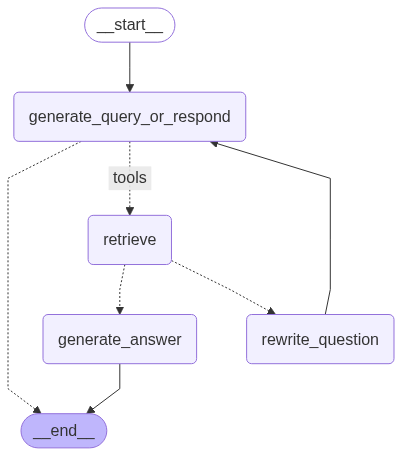

In [63]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(MessagesState)

workflow.add_node(generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retriever_tool]))
workflow.add_node(rewrite_question)
workflow.add_node(generate_answer)

workflow.add_edge(START, "generate_query_or_respond")
workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)
workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
)
workflow.add_edge("generate_answer", END)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

# Compile
graph = workflow.compile(checkpointer=MemorySaver())
display(Image(graph.get_graph().draw_mermaid_png()))

In [65]:
config = {"configurable":{"thread_id":"1"}}

for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "When did tottenham win their last trophy?",
            }
        ]
    }, config=config
):
    for node, update in chunk.items():
        print("Update from node", node)
        update["messages"][-1].pretty_print()
        print("\n\n")

Update from node generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retriever_tool (70csvwh80)
 Call ID: 70csvwh80
  Args:
    query: Tottenham last trophy win date



Update from node retrieve
================================= Tool Message =================================
Name: retriever_tool

José's Plan
Amalendu P
Tottenham Hotspur hasn't won a trophy in the last 13 years, since 
they won the Carling cup in 2008 beating Chelsea at Wembley. 
For Spurs Chairman Daniel Levy, the most logical move was to 
bring in a special manager. Someone who has plenty of experience
winning trophies and making history. 
José Mourinho was appointed Manager and Head Coach of 
Tottenham Hotspur on 20th November 2019, following the 
sacking of ex-coach Mauricio Pochettinho. In his press conference
a week later, he was asked, "Do you think, not winning the final in
The Champions League pay a toll in the squad of Mauricio 
Pochettinho ?